# 🧠 Emotion Classification using Deep Learning

This notebook implements a **CNN-based facial emotion classifier** trained on grayscale 48×48 images.  
The pipeline covers:
1. Data cleaning (duplicate detection & removal)
2. Data loading & visualization
3. Preprocessing (normalization, augmentation, class weighting)
4. Model architecture design & training
5. Evaluation (classification report & confusion matrix)
6. Saving the final model & training history

---

## 📦 Import Libraries
Import all necessary libraries including NumPy, Matplotlib, TensorFlow/Keras, and scikit-learn utilities.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf 
import keras
from tensorflow.keras.utils import image_dataset_from_directory
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import ModelCheckpoint,ReduceLROnPlateau,EarlyStopping
from tensorflow.keras.layers import Conv2D,MaxPool2D,Flatten,Dropout,Dense,Activation,BatchNormalization
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
from tensorflow.keras.layers import GlobalAveragePooling2D
import hashlib
import joblib
import pickle

import warnings
warnings.filterwarnings("ignore")

# Cleaning of Raw data

### 🔍 Step 1 — Detect Duplicate Images
Use MD5 hashing to find duplicate images across Train and Test splits.  
Duplicates are categorised by severity:
- **Within same class+split** — redundant, low risk
- **Across different classes, same split** — potential mislabelling
- **Across train/test split** — **data leakage** (highest severity)

In [112]:
import hashlib
import os
from collections import defaultdict

def get_image_hash(filepath):
    
    with open(filepath, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

def find_duplicates(root_dirs):
    hash_map = defaultdict(list)  # {hash: [(filepath, root_dir, class_name), ...]}

    for root_dir in root_dirs:
        for class_name in os.listdir(root_dir):
            class_path = os.path.join(root_dir, class_name)
            if not os.path.isdir(class_path):
                continue
                
            for filename in os.listdir(class_path):
                filepath = os.path.join(class_path, filename)
                try:
                    file_hash = get_image_hash(filepath)
                    hash_map[file_hash].append((filepath, root_dir, class_name))

                except Exception as e:
                    print(f"Skipped {filepath}: {e}")

    duplicates = {h: paths for h, paths in hash_map.items() if len(paths) > 1}
    return duplicates

duplicates = find_duplicates(["Train data", "Test data"])

print(f"Total duplicate groups found: {len(duplicates)}")
print(f"Total duplicate files (excess copies): {sum(len(v) - 1 for v in duplicates.values())}")

#Categorization:how actually are dduplicates present
within_class = 0
cross_class_same_split = 0
cross_train_test = 0

for file_hash, entries in duplicates.items():
    root_dirs_seen = set(e[1] for e in entries)
    class_names_seen = set(e[2] for e in entries)

    if len(root_dirs_seen) > 1:
        cross_train_test += 1
    elif len(class_names_seen) > 1:
        cross_class_same_split += 1
    else:
        within_class += 1

print(f"\nDuplicates within same class+split (redundant, low severity): {within_class}")
print(f"Duplicates across different classes, same split (mislabeling risk): {cross_class_same_split}")
print(f"Duplicates across train/test split (data leakage, HIGH severity): {cross_train_test}")


Total duplicate groups found: 1516
Total duplicate files (excess copies): 1853

Duplicates within same class+split (redundant, low severity): 953
Duplicates across different classes, same split (mislabeling risk): 32
Duplicates across train/test split (data leakage, HIGH severity): 531


### 🧹 Step 2 — Remove Duplicate Images
Apply an automated cleanup strategy:
- Cross train/test duplicates → keep test copy, delete train copy
- Same-class redundancies → keep one, delete the rest
- Cross-class conflicts → flag for manual review

In [114]:
#TO clean those founded duplicates

def cleanup_duplicates(duplicates, dry_run=False):

    to_delete = []
    manual_review = []

    for file_hash, entries in duplicates.items():
        root_dirs_seen = set(e[1] for e in entries)
        class_names_seen = set(e[2] for e in entries)

        if len(root_dirs_seen) > 1:
            # Cross train/test — keep Test copies, delete Train copies
            test_copies = [e for e in entries if e[1] == "Test data"]
            train_copies = [e for e in entries if e[1] == "Train data"]

            if len(test_copies) == 0:
                # No test copy exists somehow — keep one train copy, delete rest
                to_delete.extend(train_copies[1:])
            else:
                # Keep all test copies as-is, delete every train copy
                to_delete.extend(train_copies)

            # If this same group ALSO spans multiple classes, flag it too
            if len(class_names_seen) > 1:
                manual_review.append(entries)

        elif len(class_names_seen) > 1:
            # Same split, but different class folders — genuine label conflict
            manual_review.append(entries)

        else:
            # Redundant duplicate within same class+split — keep one, delete rest
            to_delete.extend(entries[1:])

    
    print(f"Files marked for deletion: {len(to_delete)}")
    print(f"Groups flagged for manual review (label conflicts): {len(manual_review)}")

    if dry_run:
        print("\n[DRY RUN] No files deleted. Showing first 10 deletion candidates:")
        for entry in to_delete[:10]:
            print(f"  Would delete: {entry[0]}")
    else:
        deleted_count = 0
        for filepath, root_dir, class_name in to_delete:
            try:
                os.remove(filepath)
                deleted_count += 1
            except Exception as e:
                print(f"Failed to delete {filepath}: {e}")
        print(f"\nActually deleted {deleted_count} files.")

    return to_delete, manual_review


to_delete, manual_review = cleanup_duplicates(duplicates, dry_run=False)

Files marked for deletion: 1771
Groups flagged for manual review (label conflicts): 57

Actually deleted 1771 files.


### 👁️ Step 3 — Visualise Label-Conflict Groups
Display images that were flagged because the same file appeared under **different emotion labels**.
This helps decide which label (if any) is correct.

Group #0: skipped (only 1 file(s) remain after cleanup)


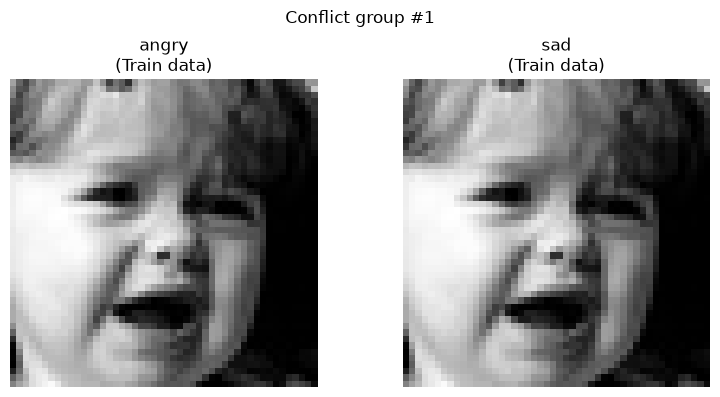

Group #2: skipped (only 1 file(s) remain after cleanup)


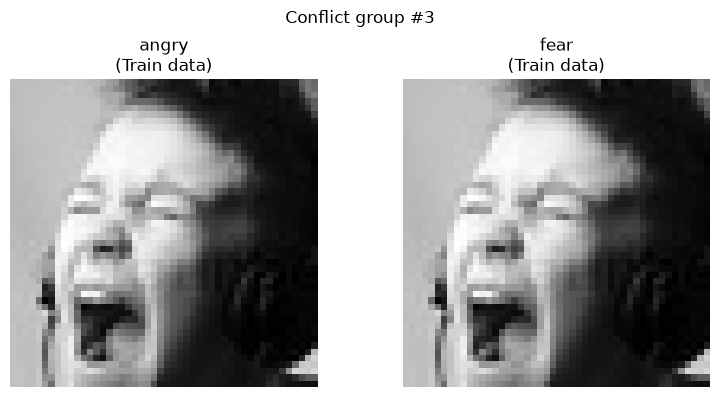

Group #4: skipped (only 1 file(s) remain after cleanup)


In [115]:
#  Visually inspect manual-review groups (cross-class duplicate labels)
import matplotlib.pyplot as plt
from PIL import Image
import os

def show_conflict_group(group, group_index):
    # Keep only entries whose file still exists
    existing = [entry for entry in group if os.path.exists(entry[0])]

    if len(existing) < 2:
        print(f"Group #{group_index}: skipped (only {len(existing)} file(s) remain after cleanup)")
        return

    n = len(existing)
    plt.figure(figsize=(4 * n, 4))
    for i, entry in enumerate(existing):
        img_path, split_name, class_name = entry
        img = Image.open(img_path)
        plt.subplot(1, n, i + 1)
        plt.imshow(img, cmap='gray')
        plt.title(f"{class_name}\n({split_name})")
        plt.axis('off')
    plt.suptitle(f"Conflict group #{group_index}")
    plt.tight_layout()
    plt.show()

# Show the first 5 conflict groups to start with
for idx, group in enumerate(manual_review[:5]):
    show_conflict_group(group, idx)

### ✂️ Step 4 — Resolve Remaining Conflicts
For each conflict group that still has multiple surviving copies, keep only the **first** file and delete the rest.

In [116]:
# For each conflict group, keep only the first surviving copy,delete the rest.

deleted_count = 0
for group in manual_review:
    existing = [entry for entry in group if os.path.exists(entry[0])]
    if len(existing) < 2:
        continue  # already resolved by earlier cleanup

    # Keep the first, delete the rest
    for img_path, split_name, class_name in existing[1:]:
        os.remove(img_path)
        deleted_count += 1

print(f"Deleted {deleted_count} additional conflicting duplicate files.")

Deleted 49 additional conflicting duplicate files.


### 📊 Step 5 — Post-Cleanup Class Distribution
Print per-class image counts for both Train and Test sets after cleaning.

In [117]:

for split in ["Train data", "Test data"]:
    print(f"\n{split}")
    total = 0
    for cls in sorted(os.listdir(split)):
        path = os.path.join(split, cls)
        if os.path.isdir(path):
            n = len(os.listdir(path))
            total += n
            print(f"{cls:<10}: {n}")
    print(f"Total: {total}")


Train data
angry     : 3790
disgust   : 352
fear      : 3809
happy     : 7031
neutral   : 4823
sad       : 4677
surprise  : 2460
Total: 26942

Test data
angry     : 954
disgust   : 110
fear      : 1016
happy     : 1768
neutral   : 1226
sad       : 1240
surprise  : 811
Total: 7125


### 🛡️ Step 6 — Verify Image Integrity
Open and verify every image file using `PIL.Image.verify()` to detect any corrupt/truncated files that could crash training.

In [119]:
##Checking for corrupt files

corrupt_count_train = 0
total_train = 0

for root, dir, files in os.walk("Train data"):
    for file in files:
        img_path = os.path.join(root, file)
        total_train += 1
        try:
            with open(img_path, "rb") as f:
                img = Image.open(f)
                img.verify()
        except Exception as e:
            print("error", e)
            print(img_path)
            corrupt_count_train += 1

print("Corrupt images checked")
print(f"Train checked: {total_train}, Corrupt: {corrupt_count_train}")


corrupt_count_test = 0
total_test = 0

for root, dir, files in os.walk("Test data"):
    for file in files:
        img_path = os.path.join(root, file)
        total_test += 1
        try:
            with open(img_path, "rb") as f:
                img = Image.open(f)
                img.verify()
        except Exception as e:
            print("error", e)
            print(img_path)
            corrupt_count_test += 1

print("Corrupt images checked")
print(f"Test checked: {total_test}, Corrupt: {corrupt_count_test}")

print(f"\nTotal corrupt files (train + test): {corrupt_count_train + corrupt_count_test}")

Corrupt images checked
Train checked: 26942, Corrupt: 0
Corrupt images checked
Test checked: 7125, Corrupt: 0

Total corrupt files (train + test): 0


### 📈 Visualise Class Distribution (Train vs Test)
Side-by-side bar chart showing how many images each emotion class has in Train vs Test after cleanup.

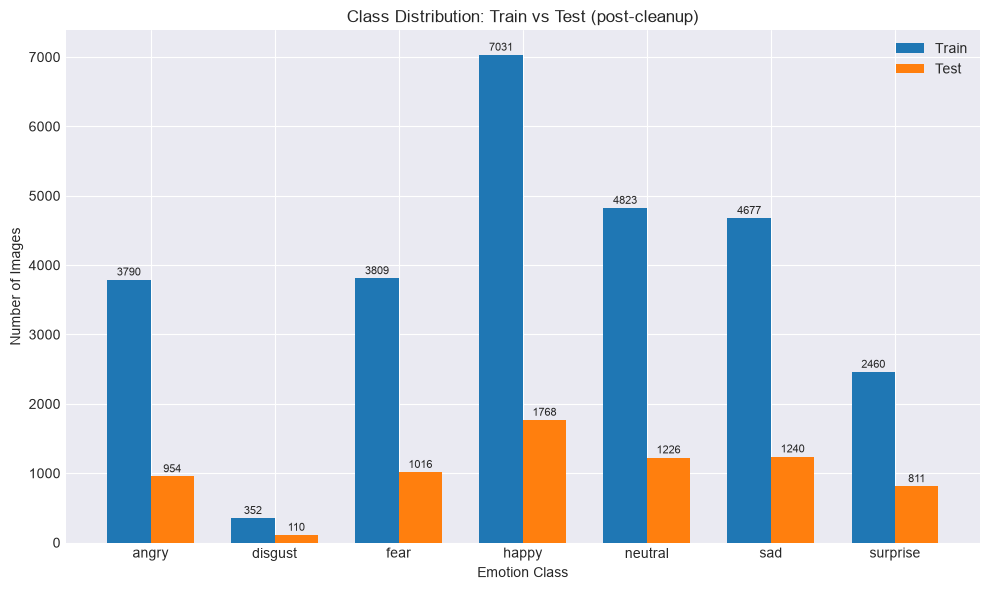

In [66]:
##Data visualization
train_counts = [3790, 352, 3809, 7031, 4823, 4677, 2460]
test_counts = [954, 110, 1016, 1768, 1226, 1240, 811]
x = np.arange(len(class_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, train_counts, width, label='Train')
bars2 = ax.bar(x + width/2, test_counts, width, label='Test')

ax.set_xlabel('Emotion Class')
ax.set_ylabel('Number of Images')
ax.set_title('Class Distribution: Train vs Test (post-cleanup)')
ax.set_xticks(x)
ax.set_xticklabels(class_names)
ax.legend()

# Add count labels on top of each bar
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height}', xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', fontsize=8)

plt.tight_layout()
plt.savefig("class-distribution.png",dpi=500)
plt.show()



## <span style="color: #E3242B; font-size: 28px; font-weight: bold;">Data Loading</span>

### 📂 Load Image Datasets
Use `image_dataset_from_directory` to create:
- **Training set** (80% of Train data)
- **Validation set** (20% of Train data)
- **Test set** (full Test data)

All images are resized to **48×48** and loaded in **grayscale** mode.

In [7]:
import os
class_names=os.listdir("Train data")
print(class_names)

['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [6]:
train_data=image_dataset_from_directory("Train data",batch_size=32,image_size=(48,48),
                                        labels='inferred',label_mode="categorical",
                                        validation_split=0.2,subset="training",
                                        shuffle=True,seed=42,color_mode="grayscale")

val_data=image_dataset_from_directory("Train data",batch_size=32,image_size=(48,48),
                                        labels='inferred',label_mode="categorical",
                                        validation_split=0.2,subset="validation",
                                        shuffle=False,seed=42,color_mode="grayscale")


test_data=image_dataset_from_directory("Test data",batch_size=32,image_size=(48,48),
                                        labels='inferred',label_mode="categorical",
                                        seed=42,color_mode="grayscale",shuffle=False)

label_dataset = image_dataset_from_directory( "Train data",
                                            labels="inferred",label_mode="int",     
                                            class_names=class_names,
                                            validation_split=0.2,subset="training",
                                            image_size=(48, 48),batch_size=32,color_mode="grayscale",shuffle=True,
                                            seed=42)

Found 28709 files belonging to 7 classes.
Using 22968 files for training.
Found 28709 files belonging to 7 classes.
Using 5741 files for validation.
Found 7178 files belonging to 7 classes.
Found 28709 files belonging to 7 classes.
Using 22968 files for training.


### 🖼️ Preview Sample Training Images
Display a grid of 20 sample images from one training batch along with their labels and pixel-value statistics.

0.0
239.0
(32, 48, 48, 1)


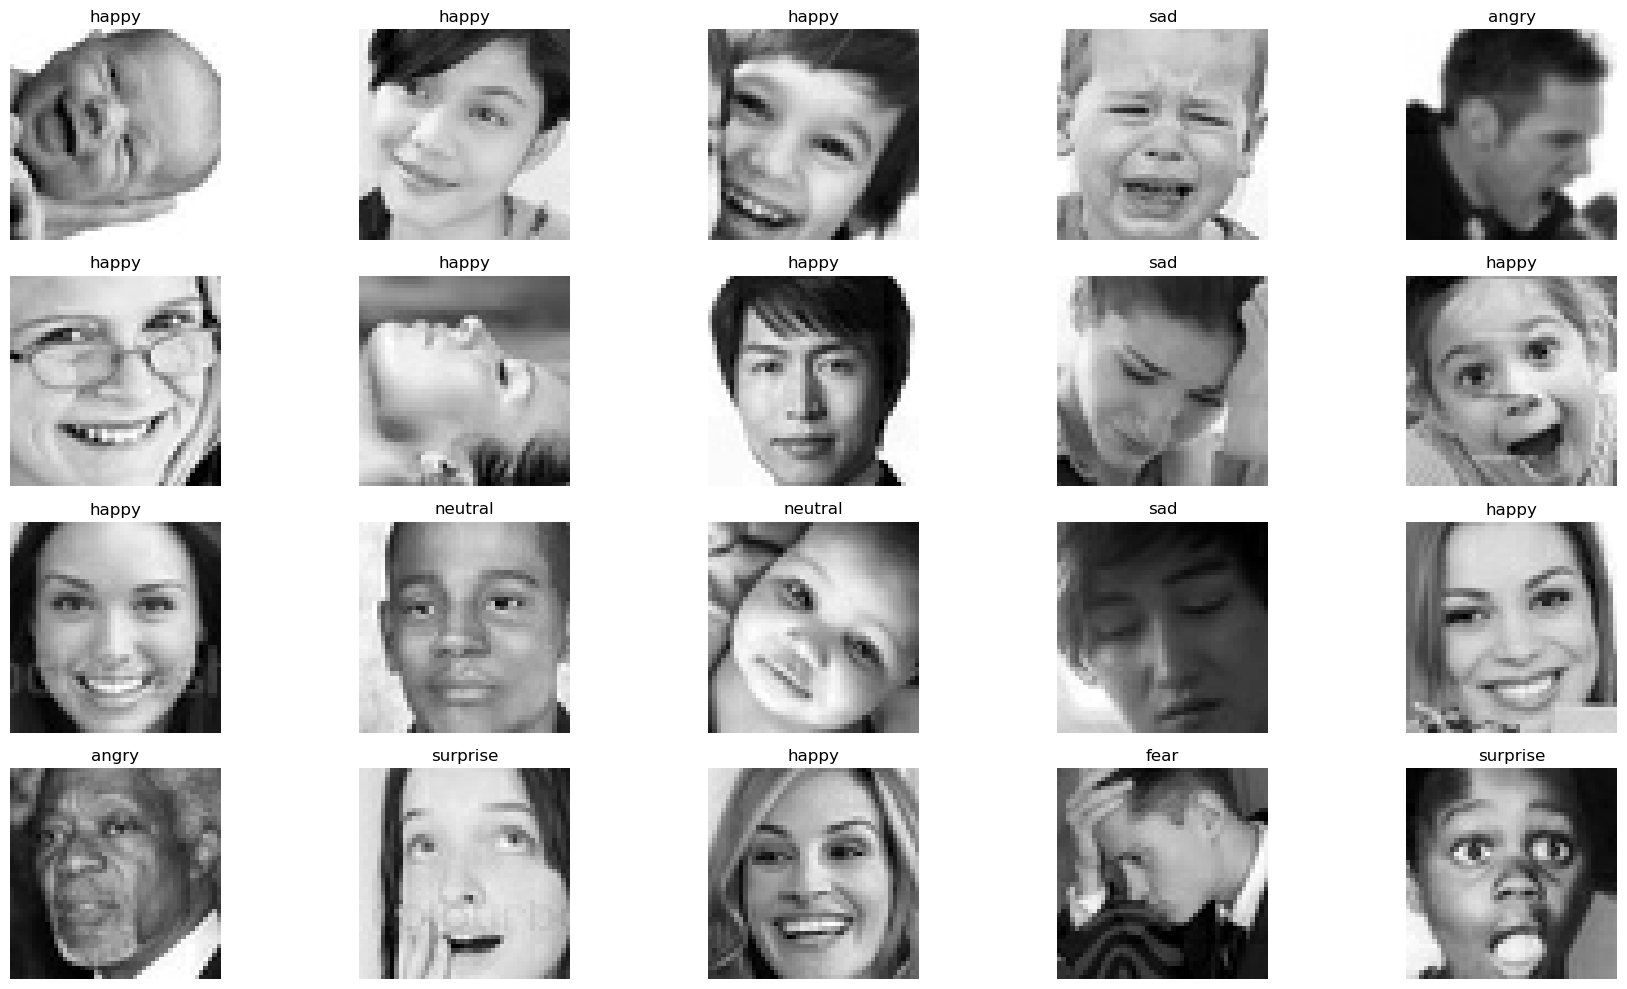

In [8]:
for images,label in train_data.take(1):
    plt.figure(figsize=(20,10))

    for i in range(20): 
        plt.subplot(4,5,i+1)
        plt.imshow(images[i].numpy(),cmap="gray")
        plt.title(train_data.class_names[np.argmax(label[i])])
        plt.axis("OFF")
        plt.tight_layout()

    print(images[1].numpy().min())
    print(images[1].numpy().max())
    print(images.shape)

## <span style="color: #BC544B; font-size:28px; font-weight: bold;">PreProcessing </span>

### 🔢 Pixel Normalization
Apply a `Rescaling(1./255)` layer so pixel values are mapped from [0, 255] → [0, 1].  
This is embedded as a Keras layer so the same transformation is automatically applied at inference time.

In [7]:
##normalization - using layer normalization so that normalization works in model itself
normalization_layer=tf.keras.layers.Rescaling(1./255)

### 🔄 Data Augmentation Pipeline
Apply random transformations during training to improve generalisation:
- Horizontal flip
- Small rotation (±10°)
- Zoom (±10%)
- Translation (±5%)

In [8]:
## General Data Aaugmentation

data_augmentation=tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomTranslation(0.05, 0.05)
])

### ⚖️ Compute Class Weights
Use `compute_class_weight('balanced', ...)` to assign higher loss penalties to under-represented classes (e.g., *disgust*).

In [9]:
#Adding class weights to resolve class imbalance

labels = np.concatenate([y.numpy() for x, y in label_dataset])

weights=compute_class_weight(class_weight="balanced",classes=np.unique(labels),
                                  y=labels)

class_weights=dict(enumerate(weights))

In [10]:
for i, weight in class_weights.items():
    print(f"{class_names[i]:10s} : {weight:.2f}")

angry      : 1.01
disgust    : 10.65
fear       : 1.01
happy      : 0.54
neutral    : 0.80
sad        : 0.84
surprise   : 1.57


### 📉 Dampen Extreme Weights
Apply a square-root transformation to the raw class weights so that extreme values (like *disgust* ≈ 10.65) are smoothed out.

In [11]:
class_weights_damped = {k: float(np.sqrt(v)) for k, v in class_weights.items()}
for i,weightss in class_weights_damped.items():
    print(f"{class_names[i]:<10} : {weightss:.2f}")

angry      : 1.01
disgust    : 3.26
fear       : 1.00
happy      : 0.74
neutral    : 0.89
sad        : 0.91
surprise   : 1.25


### ⚡ Performance Optimization
Cache datasets in memory and prefetch batches using `tf.data.AUTOTUNE` to minimise I/O bottlenecks during training.

In [12]:
##Optimization
AUTOTUNE = tf.data.AUTOTUNE
train_data= train_data.cache().prefetch(AUTOTUNE)
val_data = val_data.cache().prefetch(AUTOTUNE)
test_data = test_data.cache().prefetch(AUTOTUNE)

## <span style="color: #730079; font-size:28px; font-weight: bold;">Model work</span>

### 🛠️ Define Training Callbacks
Set up three Keras callbacks:
1. **ModelCheckpoint** — save the best model (by `val_accuracy`)
2. **EarlyStopping** — halt training if `val_accuracy` doesn't improve for 10 epochs
3. **ReduceLROnPlateau** — halve the learning rate if `val_accuracy` stalls for 5 epochs

In [13]:
callback=[ModelCheckpoint("CNN-trained-model.keras",monitor='val_accuracy',mode='max',save_best_only=True),

           EarlyStopping(monitor="val_accuracy",mode="max",patience=10,restore_best_weights=True,start_from_epoch=10),

        ReduceLROnPlateau(monitor="val_accuracy",mode="max",factor=0.5,patience=5,verbose=1)]

### 🏗️ Build the CNN Architecture
A 4-block Sequential CNN:
| Block | Filters | Key Layers |
|-------|---------|------------------------------------------|
| 1     | 32      | Conv→BN→ReLU → Conv→BN→ReLU → MaxPool → Dropout(0.25) |
| 2     | 64      | Conv→BN→ReLU → Conv→BN→ReLU → MaxPool → Dropout(0.25) |
| 3     | 128     | Conv→BN→ReLU → Conv→BN→ReLU → MaxPool → Dropout(0.25) |
| 4     | 256     | Conv→BN→ReLU → Conv→BN→ReLU → Dropout(0.25) |

Followed by **GlobalAveragePooling2D → Dense(256) → Dropout(0.5) → Dense(7, softmax)**.

In [75]:
##for imporving prev model trying a new model
Cnn_model=tf.keras.models.Sequential([tf.keras.layers.Input(shape=(48,48,1)),
                                         normalization_layer,data_augmentation, 
                                       #block1   
                                         Conv2D(32,kernel_size=(3,3),padding="same",use_bias=False),
                                          BatchNormalization(),
                                          Activation("relu"),
                                          
                                          Conv2D(32,kernel_size=(3,3),padding="same",use_bias=False),
                                          BatchNormalization(), 
                                          Activation("relu"), 
                                          MaxPool2D(pool_size=(2,2)),
                                          Dropout(0.25),

                                    #Block2 
                                          Conv2D(64,kernel_size=(3,3),padding="same",use_bias=False),
                                          BatchNormalization(),
                                          Activation("relu"),
                                          
                                          Conv2D(64,kernel_size=(3,3),padding="same",use_bias=False),
                                          BatchNormalization(), 
                                          Activation("relu"), 
                                          MaxPool2D(pool_size=(2,2)),
                                          Dropout(0.25),

                                    #Block 3 
                                          Conv2D(128,kernel_size=(3,3),padding="same",use_bias=False),
                                          BatchNormalization(), 
                                          Activation("relu"),
                                      
                                          Conv2D(128,kernel_size=(3,3),padding="same",use_bias=False),
                                          BatchNormalization(),
                                          Activation("relu"),
                                          MaxPool2D(),
                                          Dropout(0.25),
                                      
                                    #Block 4(Helps in distinguish between emotion)
                                          Conv2D(256,kernel_size=(3,3),padding="same",use_bias=False),
                                          BatchNormalization(), 
                                          Activation("relu"),
                                      
                                          Conv2D(256,kernel_size=(3,3),padding="same",use_bias=False),
                                          BatchNormalization(),
                                          Activation("relu"),
                                          Dropout(0.25),

                                          GlobalAveragePooling2D(),
                                          Dense(256,activation="relu",use_bias=False),
                                          Dropout(0.5),
                                          Dense(7,activation="softmax")
                                          ])

### ⚙️ Compile the Model
Use the **Adam** optimiser with **categorical cross-entropy** loss and track **accuracy**.

In [76]:
Cnn_model.compile(optimizer="Adam",loss="categorical_crossentropy",metrics=["accuracy"])

### 📋 Model Summary
Print the full layer-by-layer summary including output shapes and parameter counts.

In [77]:
Cnn_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)                │ (None, 48, 48, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential_1 (Sequential)            │ (None, 48, 48, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_16 (Conv2D)                   │ (None, 48, 48, 32)          │             288 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_16               │ (None, 48, 48, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_16 (Activation)           │ (None, 48, 48, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_17 (Conv2D)                   │ (None, 48, 48, 32)          │           9,216 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_17               │ (None, 48, 48, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_17 (Activation)           │ (None, 48, 48, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 24, 24, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_10 (Dropout)                 │ (None, 24, 24, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_18 (Conv2D)                   │ (None, 24, 24, 64)          │          18,432 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_18               │ (None, 24, 24, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_18 (Activation)           │ (None, 24, 24, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_19 (Conv2D)                   │ (None, 24, 24, 64)          │          36,864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_19               │ (None, 24, 24, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_19 (Activation)           │ (None, 24, 24, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 12, 12, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_11 (Dropout)                 │ (None, 12, 12, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_20 (Conv2D)                   │ (None, 12, 12, 128)         │          73,728 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 1,241,895 (4.74 MB)

 Trainable params: 1,239,975 (4.73 MB)

 Non-trainable params: 1,920 (7.50 KB)

### 🚀 Train the Model (Phase 1 — Without Class Weights)
Train for **50 epochs** without applying class weights. The callbacks will handle checkpointing, early stopping, and LR scheduling.

In [17]:
##Without Class weight 
history=Cnn_model.fit(train_data,epochs=50,
                      validation_data=val_data,
                      callbacks=callback,verbose=1)

Epoch 1/50
674/674 ━━━━━━━━━━━━━━━━━━━━ 137s 196ms/step - accuracy: 0.2586 - loss: 1.7811 - val_accuracy: 0.3628 - val_loss: 1.4940 - learning_rate: 0.0010
Epoch 2/50
674/674 ━━━━━━━━━━━━━━━━━━━━ 133s 198ms/step - accuracy: 0.3124 - loss: 1.6892 - val_accuracy: 0.3873 - val_loss: 1.9718 - learning_rate: 0.0010
Epoch 3/50
674/674 ━━━━━━━━━━━━━━━━━━━━ 136s 202ms/step - accuracy: 0.3893 - loss: 1.5606 - val_accuracy: 0.3649 - val_loss: 1.9037 - learning_rate: 0.0010
Epoch 4/50
674/674 ━━━━━━━━━━━━━━━━━━━━ 153s 227ms/step - accuracy: 0.4299 - loss: 1.4690 - val_accuracy: 0.4712 - val_loss: 1.4879 - learning_rate: 0.0010
Epoch 5/50
674/674 ━━━━━━━━━━━━━━━━━━━━ 146s 217ms/step - accuracy: 0.4510 - loss: 1.4194 - val_accuracy: 0.5685 - val_loss: 1.2449 - learning_rate: 0.0010
Epoch 6/50
674/674 ━━━━━━━━━━━━━━━━━━━━ 148s 220ms/step - accuracy: 0.4722 - loss: 1.3752 - val_accuracy: 0.5303 - val_loss: 1.2633 - learning_rate: 0.0010
Epoch 7/50
674/674 ━━━━━━━━━━━━━━━━━━━━ 128s 189ms/step - accura

### 💾 Save Training History (Phase 1)
Persist the training history dictionary (loss, accuracy, etc.) to a pickle file for later analysis.

In [62]:
#using pickle to store history 
with open("training_history1.pkl", "wb") as f:
    joblib.dump(history.history, f)

### 📥 Load the Best Saved Model
Reload the checkpoint that achieved the highest `val_accuracy` during training.

In [18]:
trained_model=tf.keras.models.load_model("CNN-trained-model.keras")

### 🔮 Generate Test-Set Predictions
Run inference on the full test set and convert one-hot predictions back to class indices.

In [19]:
y_true = np.concatenate([np.argmax(y.numpy(), axis=1) for x, y in test_data])
y_pred = np.argmax(trained_model.predict(test_data), axis=1)

223/223 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step


### 📊 Classification Report
Print precision, recall, F1-score, and support for each emotion class using scikit-learn.

In [21]:
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

       angry       0.50      0.52      0.51       954
     disgust       0.00      0.00      0.00       110
        fear       0.41      0.31      0.35      1016
       happy       0.87      0.79      0.83      1768
     neutral       0.52      0.62      0.56      1226
         sad       0.46      0.53      0.49      1240
    surprise       0.69      0.74      0.71       811

    accuracy                           0.59      7125
   macro avg       0.49      0.50      0.49      7125
weighted avg       0.59      0.59      0.59      7125



### 🗺️ Confusion Matrix
Visualise the confusion matrix as a heatmap to spot which emotions the model confuses most.

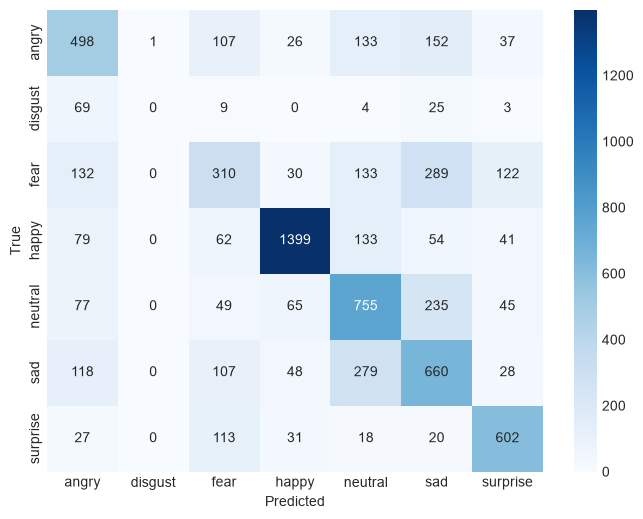

In [78]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.savefig("without Cw confusion matrix.png",dpi=300)
plt.show()

In [23]:
##Training with CW 
callback2=[ModelCheckpoint("Cnn-trained-model-CW.keras",monitor='val_accuracy',mode='max',save_best_only=True),

           EarlyStopping(monitor="val_accuracy",mode="max",patience=10,restore_best_weights=True),

        ReduceLROnPlateau(monitor="val_accuracy",mode="max",factor=0.5,patience=5,verbose=1)]

In [24]:
Cnn_model_CW=tf.keras.models.load_model("CNN-trained-model.keras")

### 🚀 Train the Model (Phase 2 — With Damped Class Weights)
Continue training with **class_weight** to help the model learn under-represented emotions like *disgust*.

In [25]:
history2=Cnn_model_CW.fit(train_data,initial_epoch=50,epochs=100,
                      callbacks=callback2,class_weight=class_weights_damped, 
                      validation_data=val_data,verbose=1)

Epoch 51/100
674/674 ━━━━━━━━━━━━━━━━━━━━ 118s 170ms/step - accuracy: 0.6135 - loss: 1.0532 - val_accuracy: 0.6470 - val_loss: 0.9743 - learning_rate: 1.2500e-04
Epoch 52/100
674/674 ━━━━━━━━━━━━━━━━━━━━ 111s 165ms/step - accuracy: 0.6133 - loss: 1.0475 - val_accuracy: 0.5932 - val_loss: 1.1000 - learning_rate: 1.2500e-04
Epoch 53/100
674/674 ━━━━━━━━━━━━━━━━━━━━ 113s 167ms/step - accuracy: 0.6182 - loss: 1.0415 - val_accuracy: 0.5974 - val_loss: 1.0853 - learning_rate: 1.2500e-04
Epoch 54/100
674/674 ━━━━━━━━━━━━━━━━━━━━ 111s 165ms/step - accuracy: 0.6106 - loss: 1.0399 - val_accuracy: 0.6078 - val_loss: 1.0534 - learning_rate: 1.2500e-04
Epoch 55/100
674/674 ━━━━━━━━━━━━━━━━━━━━ 131s 195ms/step - accuracy: 0.6127 - loss: 1.0363 - val_accuracy: 0.5870 - val_loss: 1.1095 - learning_rate: 1.2500e-04
Epoch 56/100
674/674 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.6162 - loss: 1.0344
Epoch 56: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
674/674 ━━━━━━━━━━━━━━━━

In [26]:
trained_model_CW=tf.keras.models.load_model("Cnn-trained-model-CW.keras")

In [63]:
#using pickle to store history 2
with open("training_history2.pkl", "wb") as f:
    joblib.dump(history.history, f)

In [27]:
y_pred_cw = np.argmax(trained_model_CW.predict(test_data), axis=1)
print(classification_report(y_true, y_pred_cw, target_names=class_names))

223/223 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step
              precision    recall  f1-score   support

       angry       0.50      0.51      0.50       954
     disgust       0.41      0.18      0.25       110
        fear       0.42      0.30      0.35      1016
       happy       0.90      0.79      0.84      1768
     neutral       0.52      0.65      0.57      1226
         sad       0.48      0.51      0.50      1240
    surprise       0.66      0.77      0.71       811

    accuracy                           0.60      7125
   macro avg       0.55      0.53      0.53      7125
weighted avg       0.60      0.60      0.59      7125



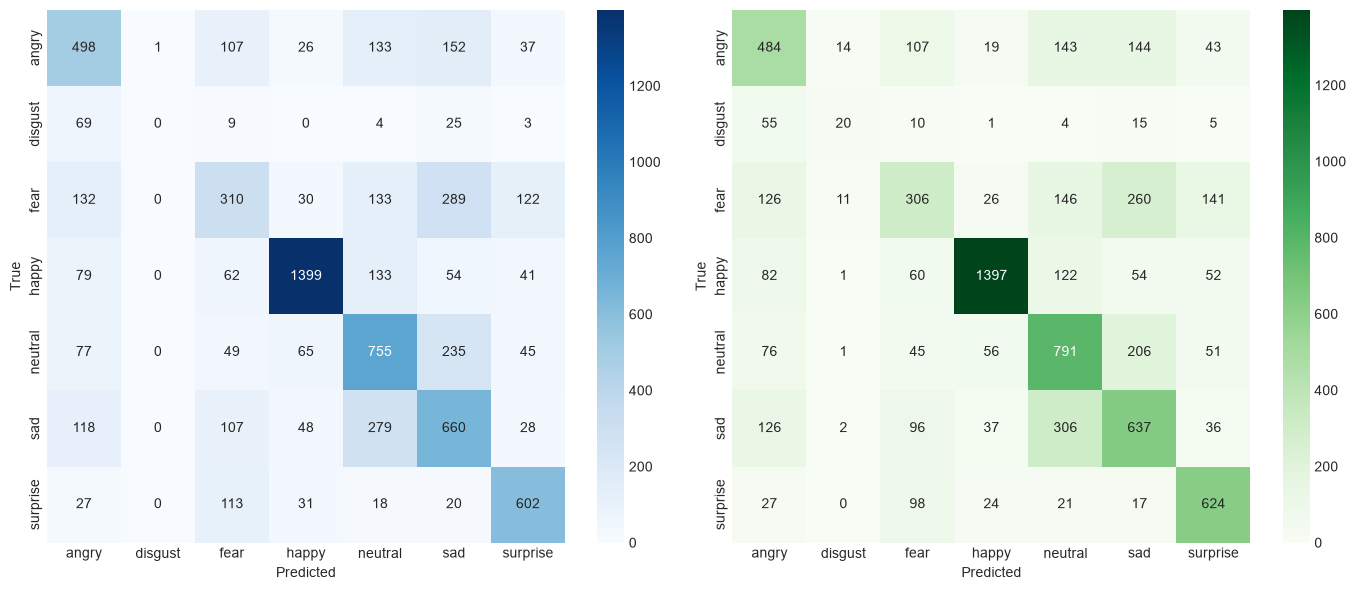

In [70]:
cm2 = confusion_matrix(y_true, y_pred_cw)
plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')

plt.subplot(1,2,2)
sns.heatmap(cm2, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.savefig("Both_correlation_matrix.png",dpi=300)
plt.show()

In [38]:
# Hence final trained model is : 
final_trained_model = trained_model_CW
final_trained_model.save("final_trained_model.keras")

### 🔗 Combine Training Histories
Merge Phase 1 and Phase 2 histories into a single dictionary for unified plotting.

In [39]:
combined_history={}
for key in history.history.keys(): 
    combined_history[key]=history.history[key] + history2.history[key]

### 💾 Save Final Combined History
Persist the merged training history for reproducibility and reporting.

In [64]:
#Storing the final history
with open("Final_history.pkl", "wb") as f:
    joblib.dump(history.history, f)

### 📐 Compute Epoch Ranges
Calculate epoch indices for Phase 1 and Phase 2 so curves can be plotted on a continuous x-axis.

In [41]:
epochs_phase1 = range(1, len(history.history['loss']) + 1)
epochs_phase2 = range(len(history.history['loss']) + 1, 
                       len(history.history['loss']) + len(history2.history['loss']) + 1)
all_epochs = list(epochs_phase1) + list(epochs_phase2)

### 📉 Plot Training & Validation Curves
Visualise **accuracy** and **loss** over both training phases to diagnose over/under-fitting.

File saved successfully


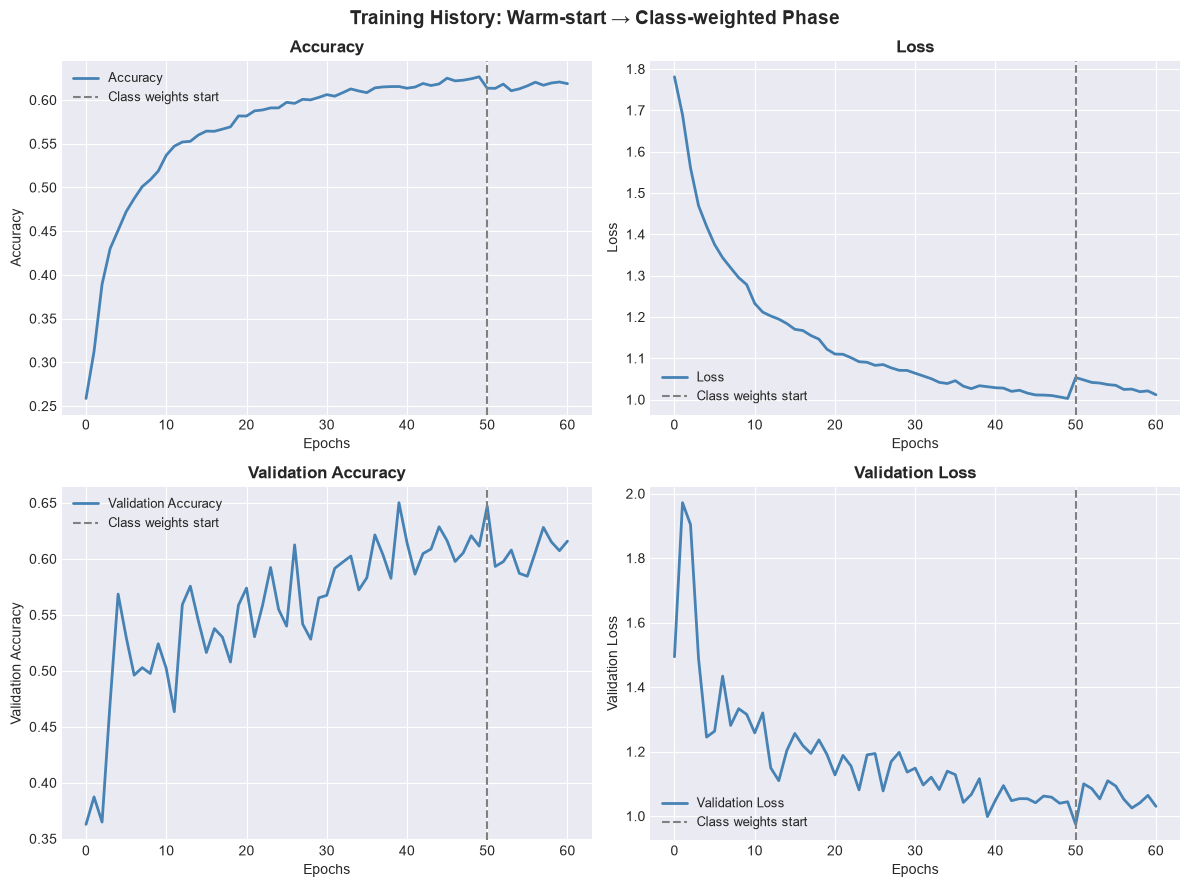

In [69]:
plt.style.use('seaborn-v0_8-darkgrid')  # cleaner grid, easier to read values off the curve

plt.figure(figsize=(12, 9))
boundary = len(history.history['accuracy']) 
metrics = [
    ('accuracy', 1, 'Accuracy'),
    ('loss', 2, 'Loss'),
    ('val_accuracy', 3, 'Validation Accuracy'),
    ('val_loss', 4, 'Validation Loss'),
]

for key, subplot_idx, title in metrics:
    plt.subplot(2, 2, subplot_idx)
    sns.lineplot(data=combined_history[key], linewidth=2, color='steelblue', label=title)
    plt.axvline(x=boundary, linestyle='--', color='gray', linewidth=1.5, label='Class weights start')
    plt.title(title, fontsize=12, fontweight='bold')
    plt.xlabel("Epochs")
    plt.ylabel(title)
    plt.legend(loc='best', fontsize=9)

plt.suptitle("Training History: Warm-start → Class-weighted Phase", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("Final plots.png",dpi=200)
print("File saved successfully")
plt.show()